# Project: Domain Adaptation via Transfer Learning

**Dataset:** Oxford Flowers 102  
**Task:** 102-class image classification  
**Backbones:** MobileNetV2 vs ResNet-50  

---

### Dataset Split Rationale
The official Oxford Flowers 102 `train` split has only ~1,020 images (~10/class), which is too small for stable 102-way classification. The official `train` and `val` splits is therefore combined (~2,040 images total) and our own 80/20 stratified split is created. The official `test` split (6,149 images) is kept entirely untouched for final evaluation.

## Imports 

In [ ]:
# Uncomment to install if needed

# !pip install grad-cam

# import sys
# !{sys.executable} -m pip install grad-cam

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import Flowers102

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
# Official Oxford Flowers 102 class names (0-indexed, matches dataset labels) # kept to make it easier to interpret results and visualize CAMs
FLOWER_NAMES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',
    'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood',
    'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle',
    'yellow iris', 'globe flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
    'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger',
    'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian',
    'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist',
    'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
    'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil',
    'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold',
    'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy',
    'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium',
    'orange dahlia', 'pink and yellow dahlia', 'cautleya spicata', 'japanese anemone',
    'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus',
    'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
    'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily',
    'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert rose',
    'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum',
    'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
    'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
]

## 1. Data Loading & Split

In [3]:
# Download raw datasets without transforms — transforms are applied after splitting
raw_train = Flowers102(root='data', split='train', download=True)
raw_val   = Flowers102(root='data', split='val',   download=True)
raw_test  = Flowers102(root='data', split='test',  download=True)

# Combine official train + val into one pool (~2,040 images)
combined = torch.utils.data.ConcatDataset([raw_train, raw_val])

# Extract labels for stratified splitting
labels_train = [raw_train[i][1] for i in range(len(raw_train))]
labels_val   = [raw_val[i][1]   for i in range(len(raw_val))]
all_labels   = labels_train + labels_val
all_indices  = list(range(len(combined)))

# Stratified 80/20 split — ensures each class is proportionally represented
train_idx, val_idx = train_test_split(
    all_indices, test_size=0.2, stratify=all_labels, random_state=42
)

print(f'Pool size:  {len(combined)}')
print(f'Train size: {len(train_idx)}')
print(f'Val size:   {len(val_idx)}')
print(f'Test size:  {len(raw_test)}'  )

Pool size:  2040
Train size: 1632
Val size:   408
Test size:  6149


## 2. Transforms & Augmentation

Augmentations could be  useful for Flowers102 because viewpoint and lighting can vary and backgrounds can be misleading (similar green/blurred backgrounds across classes). Moreover, also done based on assignment instructions.

In [ ]:
# Training transforms: 4 augmentations (plus normalize)
# Using ImageNet mean/std for normalization

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),                       # augmentation 1 -- simple flip
    T.RandomRotation(degrees=20),                   # augmentation 2 -- small random rotation
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),     # augmentation 3 -- zoom / crop
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # augmentation 4 -- color jitter
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Evaluation transforms: resize + normalize only, no augmentation 
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# Wrapper to apply per-split transforms to subsets of the combined ConcatDataset
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        return self.transform(image), label

train_dataset = TransformSubset(combined, train_idx, train_transform)
val_dataset   = TransformSubset(combined, val_idx,   eval_transform)
test_dataset  = Flowers102(root='data', split='test', download=False, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

## 3. Helper Functions

(all functions are collected here)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one training epoch, return avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(labels)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate on a loader, return loss, accuracy, all preds and labels."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * len(labels)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader, optimizer, criterion, epochs, save_path=None):
    """
    Full training loop. Returns history dict.
    If save_path is given, saves the best val-accuracy checkpoint automatically.
    This avoids the need to rebuild/retrain models later for evaluation.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Save checkpoint whenever val accuracy improves
        if save_path and vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), save_path)

        print(f'Epoch {epoch:03d} | '
              f'Train Loss {tr_loss:.4f} Acc {tr_acc:.3f} | '
              f'Val Loss {vl_loss:.4f} Acc {vl_acc:.3f}')

    return history


def plot_curves(history, title):
    """Plot loss and accuracy curves side by side."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

    plt.tight_layout()
    plt.show()


def final_test_eval(model, test_loader, criterion, model_name):
    """Run final test evaluation and print accuracy + macro F1."""
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion)
    macro_f1 = f1_score(labels, preds, average='macro')
    print(f'{model_name} — Test Acc: {test_acc:.3f} | Macro F1: {macro_f1:.3f}')
    return preds, labels


def plot_confusion_matrix_subset(preds, labels, title='Confusion Matrix (Classes 0-19)', n_classes=20):
    """Plot confusion matrix for first n_classes (full 102x102 is unreadable)."""
    cm = confusion_matrix(labels, preds, labels=list(range(n_classes)))
    disp = ConfusionMatrixDisplay(cm, display_labels=list(range(n_classes)))
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, colorbar=False, xticks_rotation='vertical')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


criterion = nn.CrossEntropyLoss()

# Note on softmax: CrossEntropyLoss applies log-softmax internally for numerical
# stability. Softmax is NOT added as an explicit layer during training.
# For inference probabilities: torch.softmax(model(x), dim=1)

## 4. Model Definitions & Utilities

All model builders, freeze/unfreeze helpers, and optimizer factories are defined here so every subsequent section can call them cleanly without rebuilding code on the fly.

#### Design note: GAP vs Flatten
Both MobileNetV2 and ResNet-50 already include a Global Average Pooling (GAP) layer before their classifier. GAP collapses the spatial dimensions (7×7) into a single vector per channel which drastically reduced the head's parameter count vs. Flatten. Implemented this in Section 8 for the exact numbers.

In [ ]:
# """" MobileNetV2 """"""

def build_mobilenet_tl():
    """
    Load ImageNet-pretrained MobileNetV2 and attach a new head for 102 classes.
    Head structure: GAP (built-in) → Dropout → Linear(1280, 102)
    All backbone weights start frozen.
    """
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier; new layers have requires_grad=True by default
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(1280, 102)
    )
    return model


def unfreeze_last_n_blocks_mv2(model, n):
    """
    Unfreeze the last n blocks of MobileNetV2's features (19 blocks total, indices 0-18).
    Stage 1: n=0 (head only) | Stage 2: n=1 | Stage 3: n=3
    """
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    if n > 0:
        for block in list(model.features.children())[-n:]:
            for param in block.parameters():
                param.requires_grad = True


def make_optimizer_mv2(model, head_only=False):
    """
    Per-layer LR strategy (grad student requirement):
      - Backbone (unfrozen): lr=1e-5 — small to preserve ImageNet features
      - Head:                lr=1e-3 — larger since weights are randomly initialized
    If head_only=True, uses a single lr=1e-3 (backbone is fully frozen anyway).
    """
    if head_only:
        return optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    backbone_params = [p for n, p in model.named_parameters()
                       if p.requires_grad and 'classifier' not in n]
    head_params     = [p for n, p in model.named_parameters()
                       if p.requires_grad and 'classifier' in n]
    return optim.Adam([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': head_params,     'lr': 1e-3}
    ])


# """""" ResNet-50 """"""

def build_resnet50_tl():
    """
    Load ImageNet-pretrained ResNet-50 and attach a new head for 102 classes.
    Head structure: GAP (built-in AdaptiveAvgPool2d) → Dropout → Linear(2048, 102)
    All backbone weights start frozen.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 102)
    )
    return model


def unfreeze_last_n_layers_resnet(model, n):
    """
    Unfreeze the last n layer groups of ResNet-50 (groups: layer1–layer4).
    Stage 1: n=0 (head only) | Stage 2: n=1 (layer4) | Stage 3: n=3 (layer2–4)
    """
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    if n > 0:
        for group in [model.layer1, model.layer2, model.layer3, model.layer4][-n:]:
            for param in group.parameters():
                param.requires_grad = True


def make_optimizer_resnet(model, head_only=False):
    """Per-layer LR: backbone 1e-5, head 1e-3. Same rationale as MobileNetV2."""
    if head_only:
        return optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    backbone_params = [p for n, p in model.named_parameters()
                       if p.requires_grad and 'fc' not in n]
    head_params     = [p for n, p in model.named_parameters()
                       if p.requires_grad and 'fc' in n]
    return optim.Adam([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': head_params,     'lr': 1e-3}
    ])


def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5. Grad-CAM Helper

Grad-CAM answers which spatial regions of the input most influenced the model's prediction for class X? It computes gradients of the class score with respect to a chosen convolutional layer's feature maps. Regions with large positive gradients are highlighted in red. These are are the pixels the model "attended to" when making its decision.

Here, its used in two ways:
1. Architecture comparison — MobileNetV2 vs ResNet-50 attention on the same image
2. Stage-to-stage shift — does attention tighten onto flower structures as more layers are unfrozen?

In [8]:
def get_gradcam_image(model, target_layer, input_tensor, label, raw_image_np):
    """
    Run Grad-CAM on one image and return an RGB overlay.
    Temporarily enables grads on all params so backprop can reach the target layer
    (frozen params have requires_grad=False, which blocks the gradient path).
    Restores the original frozen state afterward.
    """
    # Enable grads temporarily — only for visualization, does not affect weights
    for p in model.parameters():
        p.requires_grad_(True)

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(
        input_tensor=input_tensor.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(label)]
    )

    # Restore: freeze everything, then re-enable the head
    for p in model.parameters():
        p.requires_grad_(False)
    head = getattr(model, 'classifier', None) or getattr(model, 'fc', None)
    for p in head.parameters():
        p.requires_grad_(True)

    return show_cam_on_image(raw_image_np, grayscale_cam[0], use_rgb=True)


def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img = tensor * std[:, None, None] + mean[:, None, None]
    return img.permute(1, 2, 0).numpy().clip(0, 1).astype(np.float32)

## 6. Baseline Model — MobileNetV2 from Scratch

Instead of a custom CNN, MobileNetV2 with `weights=None` (random initialization) is used. Helpful later for comparison on Ablation study.

In [ ]:
baseline = models.mobilenet_v2(weights=None)
baseline.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(1280, 102)
)
baseline = baseline.to(device)
print(f'Baseline trainable parameters: {count_trainable(baseline):,}')

Baseline trainable parameters: 2,354,534


In [ ]:
BASELINE_EPOCHS = 30
TL_EPOCHS = 30

optimizer_base = optim.Adam(baseline.parameters(), lr=1e-3)
history_base = run_training(baseline, train_loader, val_loader,
                            optimizer_base, criterion, BASELINE_EPOCHS,
                            save_path='baseline_best.pth')

Epoch 001 | Train Loss 4.7074 Acc 0.020 | Val Loss 5.0702 Acc 0.010
Epoch 002 | Train Loss 4.2111 Acc 0.032 | Val Loss 4.5400 Acc 0.042
Epoch 003 | Train Loss 3.9557 Acc 0.057 | Val Loss 4.2185 Acc 0.061
Epoch 004 | Train Loss 3.7964 Acc 0.078 | Val Loss 3.6598 Acc 0.093
Epoch 005 | Train Loss 3.5682 Acc 0.096 | Val Loss 3.6315 Acc 0.132
Epoch 006 | Train Loss 3.4917 Acc 0.118 | Val Loss 3.4523 Acc 0.125
Epoch 007 | Train Loss 3.2654 Acc 0.143 | Val Loss 3.7215 Acc 0.113
Epoch 008 | Train Loss 3.2112 Acc 0.166 | Val Loss 3.0877 Acc 0.186
Epoch 009 | Train Loss 3.0915 Acc 0.184 | Val Loss 3.0874 Acc 0.206
Epoch 010 | Train Loss 2.8800 Acc 0.225 | Val Loss 3.3245 Acc 0.179
Epoch 011 | Train Loss 2.7875 Acc 0.258 | Val Loss 2.8991 Acc 0.257
Epoch 012 | Train Loss 2.7415 Acc 0.267 | Val Loss 2.8711 Acc 0.262
Epoch 013 | Train Loss 2.6044 Acc 0.292 | Val Loss 3.1368 Acc 0.252
Epoch 014 | Train Loss 2.4456 Acc 0.314 | Val Loss 2.6855 Acc 0.321
Epoch 015 | Train Loss 2.3101 Acc 0.368 | Val Lo

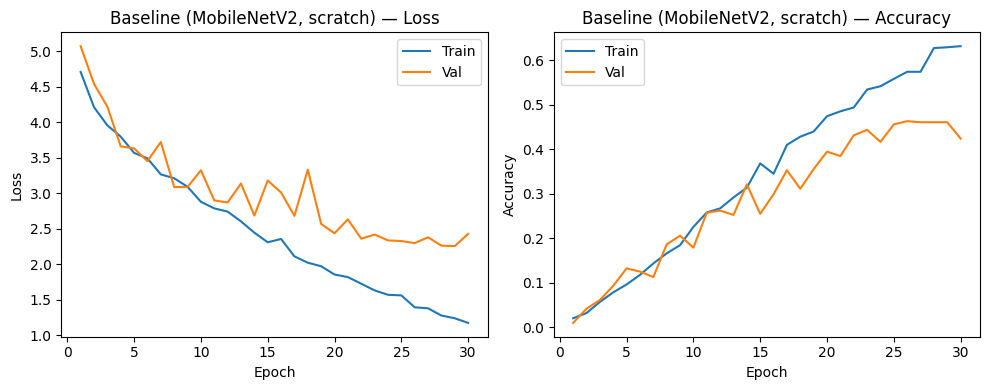

Best baseline val accuracy: 0.463


In [11]:
plot_curves(history_base, 'Baseline (MobileNetV2, scratch)')
best_baseline_acc = max(history_base['val_acc'])
print(f'Best baseline val accuracy: {best_baseline_acc:.3f}')

## 7. Transfer Learning — MobileNetV2 Ablation

Three freeze stages are trained sequentially. Each stage's best checkpoint is saved automatically by `run_training`, so we can reload any of them later for evaluation or Grad-CAM without retraining.

| Stage | Trainable portion | Optimizer LR |
|-------|------------------|--------------|
| Stage 1 | Head only | Head: 1e-3 |
| Stage 2 | Head + last 1 block | Backbone: 1e-5, Head: 1e-3 |
| Stage 3 | Head + last 3 blocks | Backbone: 1e-5, Head: 1e-3 |

In [ ]:
ablation_results = []  # will store (label, n_trainable, best_val_acc, history)

for n_blocks in [0, 1, 3]:
    print(f'\n--- MobileNetV2 Stage: {n_blocks} backbone block(s) unfrozen ---')
    model = build_mobilenet_tl().to(device)
    unfreeze_last_n_blocks_mv2(model, n_blocks)

    n_trainable = count_trainable(model)
    print(f'Trainable params: {n_trainable:,}')

    optimizer = make_optimizer_mv2(model, head_only=(n_blocks == 0))
    save_path = f'mv2_stage{n_blocks}.pth'

    history = run_training(model, train_loader, val_loader,
                           optimizer, criterion, TL_EPOCHS, save_path=save_path)
    best_acc = max(history['val_acc'])
    label = 'Head only' if n_blocks == 0 else f'Head + {n_blocks} block(s)'
    ablation_results.append((label, n_trainable, best_acc, history))
    print(f'Best val acc: {best_acc:.3f} — checkpoint saved to {save_path}')


--- MobileNetV2 Stage: 0 backbone block(s) unfrozen ---
Trainable params: 130,662
Epoch 001 | Train Loss 4.1359 Acc 0.154 | Val Loss 2.9460 Acc 0.441
Epoch 002 | Train Loss 2.3139 Acc 0.601 | Val Loss 1.9317 Acc 0.640
Epoch 003 | Train Loss 1.4856 Acc 0.768 | Val Loss 1.4380 Acc 0.713
Epoch 004 | Train Loss 1.0608 Acc 0.844 | Val Loss 1.1632 Acc 0.784
Epoch 005 | Train Loss 0.8190 Acc 0.877 | Val Loss 1.0266 Acc 0.792
Epoch 006 | Train Loss 0.6598 Acc 0.904 | Val Loss 0.9482 Acc 0.806
Epoch 007 | Train Loss 0.5739 Acc 0.911 | Val Loss 0.8549 Acc 0.819
Epoch 008 | Train Loss 0.5114 Acc 0.925 | Val Loss 0.7888 Acc 0.831
Epoch 009 | Train Loss 0.4268 Acc 0.944 | Val Loss 0.7870 Acc 0.828
Epoch 010 | Train Loss 0.4051 Acc 0.931 | Val Loss 0.7470 Acc 0.846
Epoch 011 | Train Loss 0.3610 Acc 0.958 | Val Loss 0.7055 Acc 0.831
Epoch 012 | Train Loss 0.3178 Acc 0.947 | Val Loss 0.7020 Acc 0.833
Epoch 013 | Train Loss 0.2805 Acc 0.958 | Val Loss 0.6924 Acc 0.836
Epoch 014 | Train Loss 0.2716 Acc

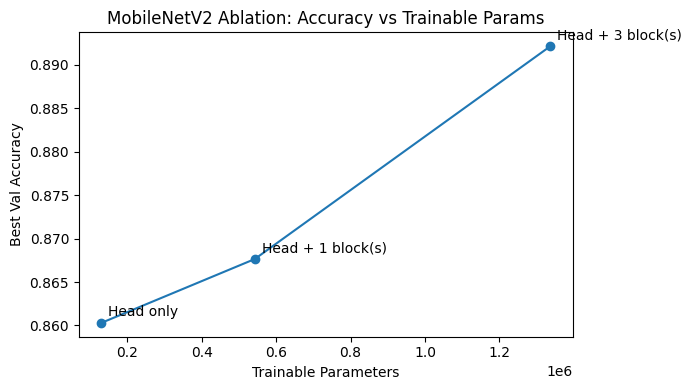

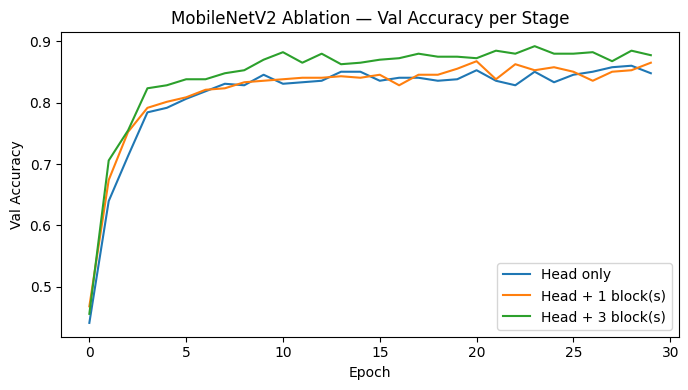

In [13]:
# Accuracy gain vs trainable parameters
labels   = [r[0] for r in ablation_results]
n_params = [r[1] for r in ablation_results]
accs     = [r[2] for r in ablation_results]

plt.figure(figsize=(7, 4))
plt.plot(n_params, accs, marker='o')
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (n_params[i], accs[i]), textcoords='offset points', xytext=(5, 5))
plt.xlabel('Trainable Parameters')
plt.ylabel('Best Val Accuracy')
plt.title('MobileNetV2 Ablation: Accuracy vs Trainable Params')
plt.tight_layout(); plt.show()

# Val accuracy curves across all stages
plt.figure(figsize=(7, 4))
for label, _, _, history in ablation_results:
    plt.plot(history['val_acc'], label=label)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.title('MobileNetV2 Ablation — Val Accuracy per Stage')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Transfer Learning — ResNet-50 Ablation

Same three-stage ablation repeated for ResNet-50. ResNet-50's backbone ends with `layer4` and its head is `model.fc`. 

In [14]:
ablation_results_rn50 = []

for n_blocks in [0, 1, 3]:
    print(f'\n--- ResNet-50 Stage: {n_blocks} layer group(s) unfrozen ---')
    model = build_resnet50_tl().to(device)
    unfreeze_last_n_layers_resnet(model, n_blocks)

    n_trainable = count_trainable(model)
    print(f'Trainable params: {n_trainable:,}')

    optimizer = make_optimizer_resnet(model, head_only=(n_blocks == 0))
    save_path = f'rn50_stage{n_blocks}.pth'

    history = run_training(model, train_loader, val_loader,
                           optimizer, criterion, TL_EPOCHS, save_path=save_path)
    best_acc = max(history['val_acc'])
    label = 'Head only' if n_blocks == 0 else f'Head + {n_blocks} layer(s)'
    ablation_results_rn50.append((label, n_trainable, best_acc, history))
    print(f'Best val acc: {best_acc:.3f} — checkpoint saved to {save_path}')


--- ResNet-50 Stage: 0 layer group(s) unfrozen ---
Trainable params: 208,998
Epoch 001 | Train Loss 4.4403 Acc 0.101 | Val Loss 3.1490 Acc 0.382
Epoch 002 | Train Loss 2.6181 Acc 0.511 | Val Loss 2.0713 Acc 0.623
Epoch 003 | Train Loss 1.7453 Acc 0.694 | Val Loss 1.5016 Acc 0.728
Epoch 004 | Train Loss 1.2760 Acc 0.776 | Val Loss 1.2218 Acc 0.755
Epoch 005 | Train Loss 1.0150 Acc 0.831 | Val Loss 1.0518 Acc 0.789
Epoch 006 | Train Loss 0.8463 Acc 0.843 | Val Loss 0.9771 Acc 0.797
Epoch 007 | Train Loss 0.6899 Acc 0.887 | Val Loss 0.8881 Acc 0.797
Epoch 008 | Train Loss 0.6215 Acc 0.895 | Val Loss 0.7865 Acc 0.821
Epoch 009 | Train Loss 0.5481 Acc 0.898 | Val Loss 0.7345 Acc 0.831
Epoch 010 | Train Loss 0.5176 Acc 0.903 | Val Loss 0.7329 Acc 0.838
Epoch 011 | Train Loss 0.4507 Acc 0.919 | Val Loss 0.6977 Acc 0.831
Epoch 012 | Train Loss 0.4015 Acc 0.928 | Val Loss 0.6964 Acc 0.838
Epoch 013 | Train Loss 0.3866 Acc 0.934 | Val Loss 0.6376 Acc 0.850
Epoch 014 | Train Loss 0.3463 Acc 0.94

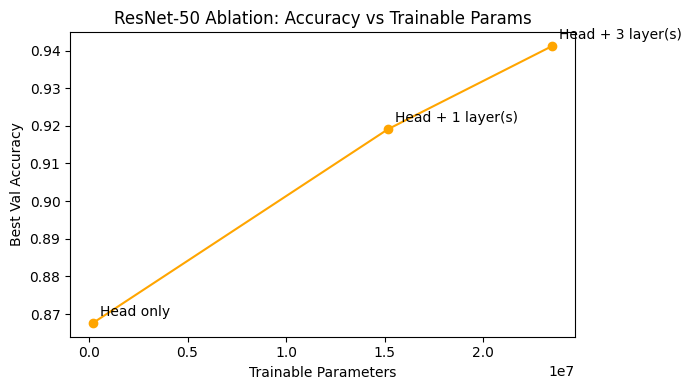

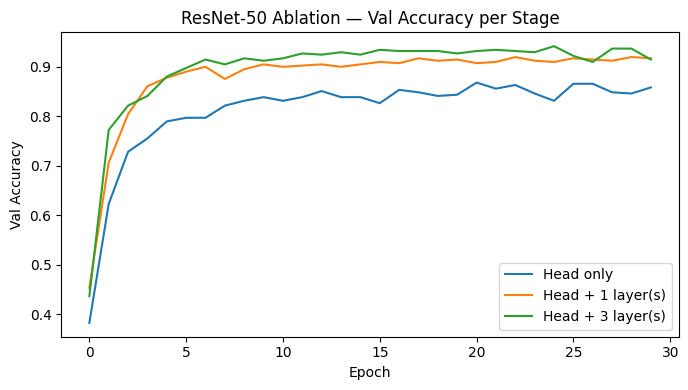

In [15]:
# Accuracy gain vs trainable parameters
labels   = [r[0] for r in ablation_results_rn50]
n_params = [r[1] for r in ablation_results_rn50]
accs     = [r[2] for r in ablation_results_rn50]

plt.figure(figsize=(7, 4))
plt.plot(n_params, accs, marker='o', color='orange')
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (n_params[i], accs[i]), textcoords='offset points', xytext=(5, 5))
plt.xlabel('Trainable Parameters')
plt.ylabel('Best Val Accuracy')
plt.title('ResNet-50 Ablation: Accuracy vs Trainable Params')
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
for label, _, _, history in ablation_results_rn50:
    plt.plot(history['val_acc'], label=label)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.title('ResNet-50 Ablation — Val Accuracy per Stage')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Overall Comparison — Baseline vs Best TL Models

In [16]:
# Load best Stage 3 checkpoints (saved during training above)
mv2_best = build_mobilenet_tl().to(device)
unfreeze_last_n_blocks_mv2(mv2_best, 3)
mv2_best.load_state_dict(torch.load('mv2_stage3.pth'))

rn50_best = build_resnet50_tl().to(device)
unfreeze_last_n_layers_resnet(rn50_best, 3)
rn50_best.load_state_dict(torch.load('rn50_stage3.pth'))

# Reload baseline best checkpoint too
baseline_eval = models.mobilenet_v2(weights=None)
baseline_eval.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, 102))
baseline_eval = baseline_eval.to(device)
baseline_eval.load_state_dict(torch.load('baseline_best.pth'))

/tmp/ipykernel_2246560/826517141.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mv2_best.load_state_dict(torch.load('mv2_stage3.pth'))
/tmp/ipykernel_2246560/826517141.

<All keys matched successfully>

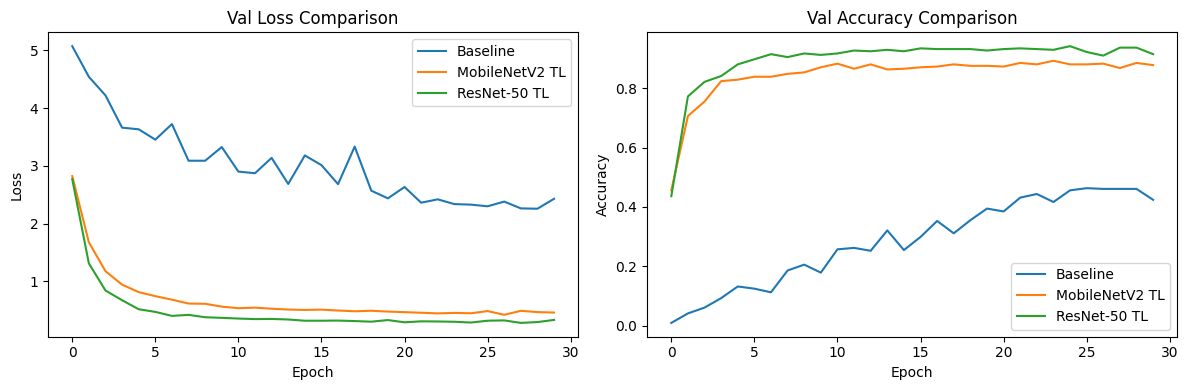

MobileNetV2 TL exceeded baseline (0.463) at epoch 2
ResNet-50 TL exceeded baseline (0.463) at epoch 2


In [17]:
history_mv2_best  = ablation_results[2][3]       # Stage 3 = index 2
history_rn50_best = ablation_results_rn50[2][3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_base['val_loss'],      label='Baseline')
ax1.plot(history_mv2_best['val_loss'],  label='MobileNetV2 TL')
ax1.plot(history_rn50_best['val_loss'], label='ResNet-50 TL')
ax1.set_title('Val Loss Comparison')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(history_base['val_acc'],      label='Baseline')
ax2.plot(history_mv2_best['val_acc'],  label='MobileNetV2 TL')
ax2.plot(history_rn50_best['val_acc'], label='ResNet-50 TL')
ax2.set_title('Val Accuracy Comparison')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.tight_layout(); plt.show()

# How many epochs for TL to beat the baseline's best val accuracy?
for label, history in [('MobileNetV2 TL', history_mv2_best),
                        ('ResNet-50 TL',   history_rn50_best)]:
    for epoch, acc in enumerate(history['val_acc'], start=1):
        if acc >= best_baseline_acc:
            print(f'{label} exceeded baseline ({best_baseline_acc:.3f}) at epoch {epoch}')
            break
    else:
        print(f'{label} never exceeded baseline val accuracy')

## 10. Final Test Evaluation

The official test set (6,149 images, untouched throughout training) used for testing. Reported both accuracy and macro F1 — macro F1 is more informative than accuracy for a 102-class fine-grained task because it weights all classes equally regardless of sample count.

In [18]:
preds_mv2,  labels_mv2  = final_test_eval(mv2_best,      test_loader, criterion, 'MobileNetV2 Stage3')
preds_rn50, labels_rn50 = final_test_eval(rn50_best,     test_loader, criterion, 'ResNet-50 Stage3')
preds_base, labels_base = final_test_eval(baseline_eval, test_loader, criterion, 'Baseline (scratch)')

MobileNetV2 Stage3 — Test Acc: 0.862 | Macro F1: 0.859
ResNet-50 Stage3 — Test Acc: 0.906 | Macro F1: 0.905
Baseline (scratch) — Test Acc: 0.409 | Macro F1: 0.393


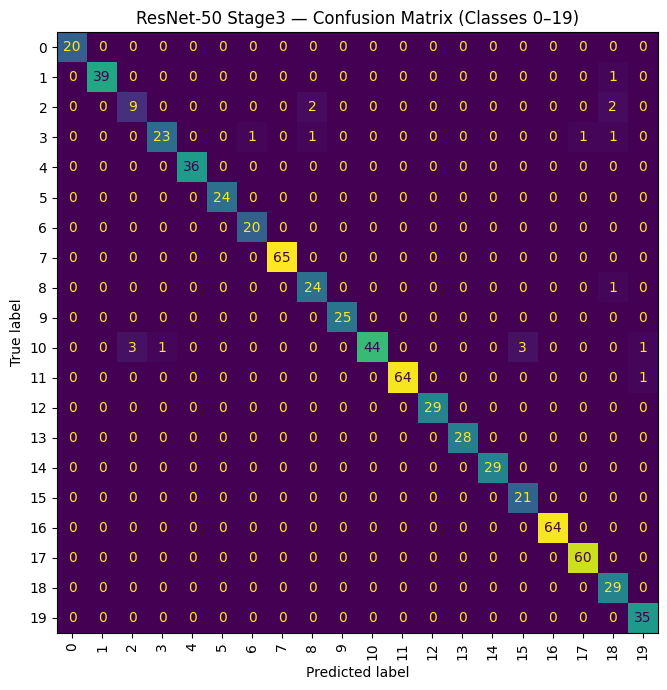

In [ ]:
# Confusion matrix for the best model (first 20 classes shown — full 102x102 is unreadable)
# Resnet-50 Stage 3 had the best test accuracy, so we visualize its confusion matrix here
plot_confusion_matrix_subset(preds_rn50, labels_rn50, title='ResNet-50 Stage3 — Confusion Matrix (Classes 0–19)')

## 11. Misclassified Examples

Two images the best model got wrong and displaying them with their true and predicted class names.

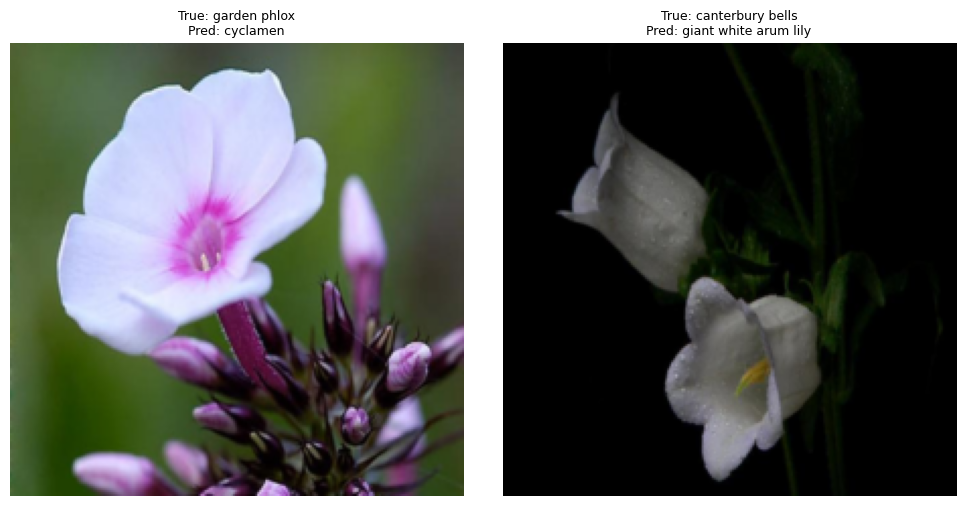

In [20]:
def show_misclassified(model, loader, n=2):
    """Find and display the first n misclassified images with true/pred class names."""
    model.eval()
    samples = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds   = outputs.argmax(1).cpu()
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    samples.append((images[i], labels[i].item(), preds[i].item()))
                if len(samples) == n:
                    break
            if len(samples) == n:
                break

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for ax, (img, true, pred) in zip(axes, samples):
        ax.imshow(denormalize(img))
        true_name = FLOWER_NAMES[true]
        pred_name = FLOWER_NAMES[pred]
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_misclassified(rn50_best, val_loader)

## 12. GAP vs Flatten — Parameter Count Analysis

"How would the number of trainable parameters change if you used a Flatten layer instead of a GAP layer? How would that affect the risk of overfitting?"

In [21]:
# MobileNetV2 produces 7x7x1280 feature maps for 224x224 input
# GAP collapses spatial dims (7x7) → 1280-dim vector
# Flatten preserves all spatial dims → 7*7*1280 = 62,720-dim vector

gap_input     = 1280
flatten_input = 7 * 7 * 1280

gap_params     = gap_input     * 102  # weights of Linear(1280, 102)
flatten_params = flatten_input * 102  # weights of Linear(62720, 102)

print(f'GAP head parameters:     {gap_params:,}')
print(f'Flatten head parameters: {flatten_params:,}')
print(f'Ratio:                   {flatten_params / gap_params:.0f}x more parameters with Flatten')
print()
print(f'With only ~1,600 training images and {flatten_params:,} head parameters,')
print('a Flatten head would severely overfit — more parameters than training samples.')
print('GAP summarizes each feature channel globally, acting as a strong regularizer.')

GAP head parameters:     130,560
Flatten head parameters: 6,397,440
Ratio:                   49x more parameters with Flatten

With only ~1,600 training images and 6,397,440 head parameters,
a Flatten head would severely overfit — more parameters than training samples.
GAP summarizes each feature channel globally, acting as a strong regularizer.


## 13. Grad-CAM Visualization

### Plot 1: Architecture comparison
MobileNetV2 vs ResNet-50 attention on the same image at Stage 3 (fully fine-tuned).

### Plot 2: Stage-to-stage attention shift (grad student requirement)
MobileNetV2 at Stage 1 (head-only, frozen backbone) vs Stage 3 (partially fine-tuned). 
Stage 1 relies on generic ImageNet features; Stage 3 adapts deeper layers to flower-specific cues like petal texture and shape.

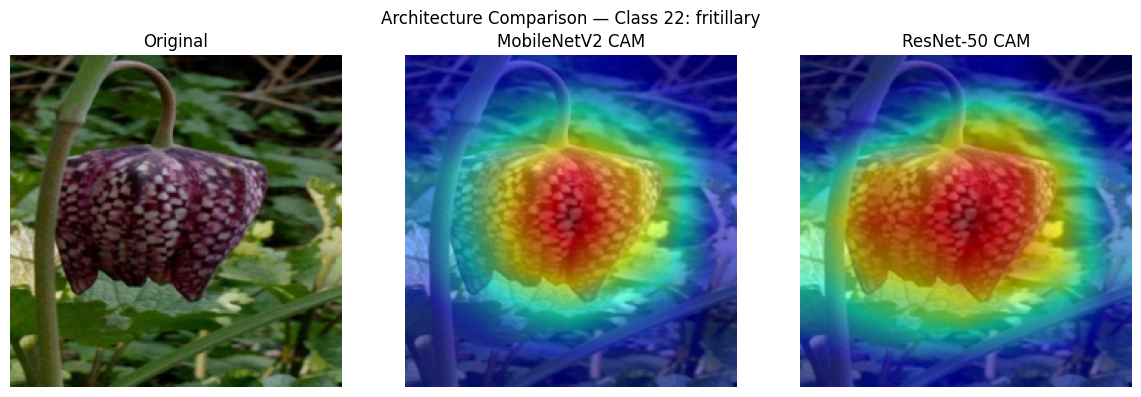

/tmp/ipykernel_2246560/4064638547.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mv2_stage1.load_state_dict(torch.load('mv2_stage0.pth'))


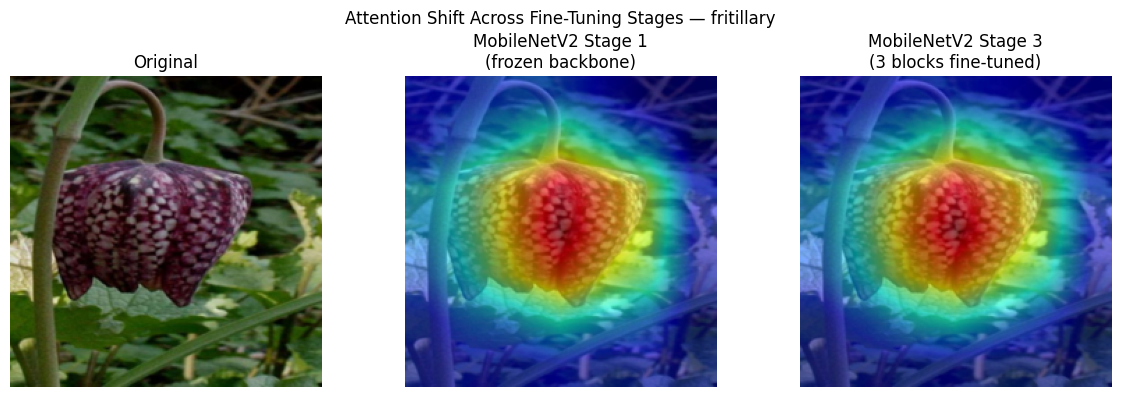

In [ ]:
# Pick a sample image
sample_idx = 0
sample_img, sample_label = val_dataset[sample_idx]
img_np     = denormalize(sample_img)
class_name = FLOWER_NAMES[sample_label]

# Target layers: go one level inside the final block (avoids Sequential wrapper issues)
mv2_target_layer  = mv2_best.features[-1][0]
rn50_target_layer = rn50_best.layer4[-1].conv3

#  Plot 1: Architecture comparison
cam_mv2  = get_gradcam_image(mv2_best,  mv2_target_layer,  sample_img, sample_label, img_np)
cam_rn50 = get_gradcam_image(rn50_best, rn50_target_layer, sample_img, sample_label, img_np)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np);   axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(cam_mv2);  axes[1].set_title('MobileNetV2 CAM'); axes[1].axis('off')
axes[2].imshow(cam_rn50); axes[2].set_title('ResNet-50 CAM');   axes[2].axis('off')
plt.suptitle(f'Architecture Comparison — Class {sample_label}: {class_name}')
plt.tight_layout(); plt.show()

#  Plot 2: Stage-to-stage shift (MobileNetV2) 
# Load Stage 1 checkpoint (head-only) — saved earlier
mv2_stage1 = build_mobilenet_tl().to(device)
mv2_stage1.load_state_dict(torch.load('mv2_stage0.pth'))

cam_stage1 = get_gradcam_image(mv2_stage1, mv2_stage1.features[-1][0],
                               sample_img, sample_label, img_np)
cam_stage3 = get_gradcam_image(mv2_best,   mv2_best.features[-1][0],
                               sample_img, sample_label, img_np)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np);     axes[0].set_title('Original');                        axes[0].axis('off')
axes[1].imshow(cam_stage1); axes[1].set_title('MobileNetV2 Stage 1\n(frozen backbone)'); axes[1].axis('off')
axes[2].imshow(cam_stage3); axes[2].set_title('MobileNetV2 Stage 3\n(3 blocks fine-tuned)'); axes[2].axis('off')
plt.suptitle(f'Attention Shift Across Fine-Tuning Stages — {class_name}')
plt.tight_layout(); plt.show()

## 14. Analysis Summary

---

**Overfitting onset:** The baseline began overfitting around epoch 20. By this time, training accuracy had reached 47.4% while validation accuracy peaked at 39.5%. The gap in the curve kept widening through epoch 30 (train 63.2%, val 42.4%). With random weights and ~1,600 training images, the model has no prior knowledge to generalize from. Transfer learning models were far more resistant. Even Stage 1 (frozen backbone, head only) reached 86% validation accuracy with a much tighter train/val gap because the frozen backbone provides pre-learned features and only the small 130K-parameter head is optimized.

**Two misclassified examples:** 

The two misclassified images show the general challenge faced. Here, garden phlox was predicted as cyclamen because both share rounded reflexed petals with a pink-centered white coloration. Similarly, in another misclassification, and canterbury bells was predicted as giant white arum lily because both present smooth white bell-to-funnel shapes. Moreover, the dark background eliminated all auxiliary contextual cues that the model could ahve used to distinguish them.

**Flowers102 vs ImageNet distance:** Flowers102 is somewhat different from ImageNet. ImageNet includes a handful of flower classes (e.g., daisy, tulip), so the early backbone layers which detect edges, color gradients, and textures can transfer well to flower images. However, the 102-class fine-grained distinctions require adaptation in deeper layers. This explains the ablation results where Stage 1 (frozen backbone) already achieves 86.0% val accuracy for MobileNetV2 and 86.8% for ResNet-50. But unlocking deeper layers pushes MobileNetV2 to 89.2% and ResNet-50 to 94.1%. The model does not need to unlearn ImageNet patterns so much.

**GAP vs Flatten:** As computed in Section 12, using Flatten would produce 49× more head parameters than GAP (6,397,440 vs 130,560) for MobileNetV2. With only ~1,600 training images, a Flatten head would have roughly 4× more parameters than training samples. It would likely result in severe overfitting. GAP summarizes each of the 1,280 feature channels into a single scalar. However, it discards the spatial position abut preserves the channel-level discriminative information the backbone learned.

**Epochs for TL to beat baseline:** Both MobileNetV2 TL and ResNet-50 TL exceeded the baseline's best validation accuracy of 46.3% at **epoch 2** itself. This is a striking result where a pretrained model with only 2 gradient steps on this dataset already outperforms a model trained from scratch for the full 30 epochs. It shows the power of transfer learning on small datasets.

**Ablation findings:** For MobileNetV2, best val accuracy improved from 86.0% (Stage 1, 130K params) to 86.8% (Stage 2, 543K params) to 89.2% (Stage 3, 1.34M params). For ResNet-50, it went from 86.8% (Stage 1, 209K params) to 91.9% (Stage 2, 15.2M params) to 94.1% (Stage 3, 23.5M params). The accuracy-vs-parameters plots show that for MobileNetV2, there is small gains per added parameter, but for ResNet-50, the benefits were higher. In ResNet-50, unfreezing layer4 (Stage 2) alone added 5.1 percentage points. It can also be seen that not all unfrozen parameters contribute equally. The ResNet-50's deeper residual blocks contain more representational capacity for fine-grained classification.

**MobileNetV2 vs ResNet-50:** ResNet-50 Stage 3 achieved the best overall performance: **90.6% test accuracy, 90.5% macro F1**, compared to MobileNetV2 Stage 3 at **86.2% test accuracy, 85.9% macro F1**. The baseline (scratch) reached only 40.9% test accuracy / 39.3% macro F1. The baseline gap is of nearly 50 percentage points vs the best model.

**Grad-CAM observations:** At Stage 1 (frozen backbone, `mv2_stage0.pth`), the model's attention covers slightly more regions including stem. That means it relies on ImageNet features and cannot yet localize flower-specific structure. At Stage 3, attention tightens a little more onto the petal body and central disc. The unfrozen backbone layers have adapted to flower discriminative cues like petal texture and shape boundaries (not quite visible nicely, but from stats, we can infer that). Both MobileNetV2 and ResNet-50 at Stage 3 show similarly focused attention on the flower. However, ResNet-50's heatmap covers the full bloom more completely. 

**Batch normalization:** BatchNorm has two modes: training mode (updates running mean/variance from the current batch) and inference mode (uses stored ImageNet statistics). When the backbone is frozen during transfer learning, inference mode is preferable (the running statistics are well-calibrated from ImageNet training on millions of images). Recomputing them from our small ~1,600 image dataset in training mode risks destabilizing the normalization. Especially during the early epochs when the head loss is large, it would be problemmatic. In this implementation, frozen BN layers remain implicitly stable since their learnable parameters (gamma/beta) are not updated. The main risk is the running stats buffer, which PyTorch does update in `model.train()` mode regardless of `requires_grad`. For maximum stability, frozen BN layers should be explicitly set to `.eval()` mode during training.